In [42]:
# Imports
import sys
sys.path.insert(1, '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/')
import importlib
import numpy as np
import awkward as ak
import pandas as pd
# from particle import Particle
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
#from mpl_toolkits.mplot3d import Axes3D
from python.analysis import BeamParticleSelection, Master, SelectionTools, vector
from python.analysis import SelectionEvaluation as seval
from python.analysis import Tags, Plots
from python.pdhd_MC import beam_selection
importlib.reload(Master)
importlib.reload(BeamParticleSelection)
importlib.reload(SelectionTools)
importlib.reload(Tags)
importlib.reload(beam_selection)

<module 'python.pdhd_MC.beam_selection' from '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/python/pdhd_MC/beam_selection.py'>

In [43]:
filename = "/storage/2/gj23442/PDSPProd4a_MC_1GeV_reco1_sce_datadriven_v1_ntuple_v09_41_00_03.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events_pdsp = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [44]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_pdsp, return_property=True)
mask = true_beam_mask[0]
bi_evts_pdsp = events_pdsp.Filter([mask], [mask], returnCopy=True)

In [45]:
mask = beam_selection.BeamValidSelection(bi_evts_pdsp)
bv_evts_pdsp = bi_evts_pdsp.Filter([mask], [mask], returnCopy=True)
mask = beam_selection.BeamTrackSelection(bv_evts_pdsp)
track_evts_pdsp = bv_evts_pdsp.Filter([mask], [mask], returnCopy=True)

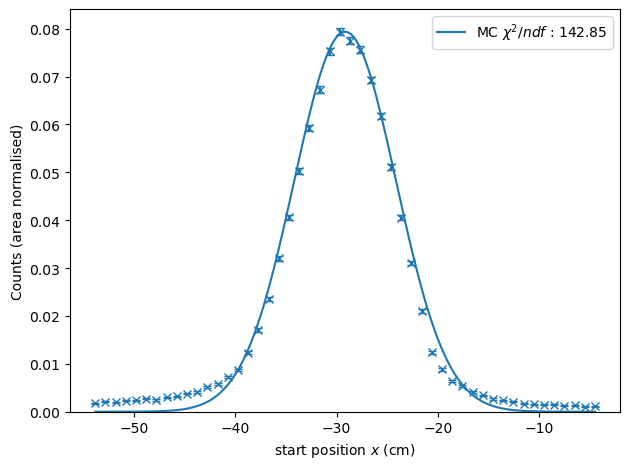

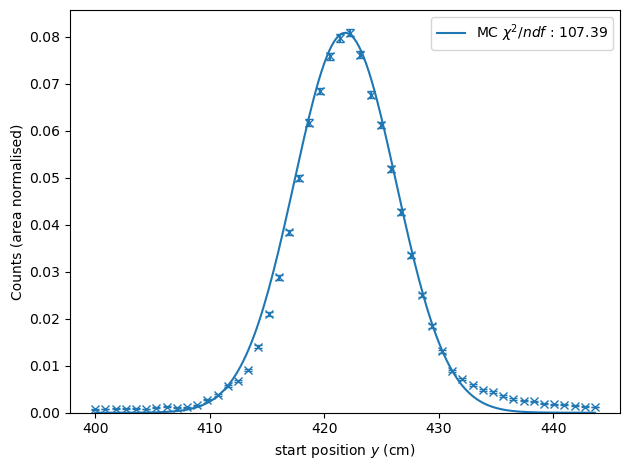

In [46]:
import apps.cex_beam_quality_fits as beam_qual

reco_startpos = track_evts_pdsp.recoParticles.beam_startPos
mu, mu_err, sigma, sigma_err = beam_selection.BeamQualityPosition(track_evts_pdsp)

def plot_range(mu, sigma):
    return [mu - 5*sigma, mu + 5*sigma]

plot_ranges = {i: plot_range(mu[i], sigma[i]) for i in ["x", "y"]}

for i in ["x", "y"]:
    beam_qual.plot(reco_startpos[i], f"start position ${i}$ (cm)", mu[i], sigma[i], "C0", "MC", range = [min(plot_ranges[i]), max(plot_ranges[i])])
    plt.show()

In [47]:
reco_startpos = track_evts_pdsp.recoParticles.beam_startPos

beam_dx = (reco_startpos.x - mu["x"])/ sigma["x"] 
beam_dy = (reco_startpos.y - mu["y"])/ sigma["y"]
beam_dxy = (beam_dx**2 + beam_dy**2)**0.5

<Figure size 800x600 with 0 Axes>

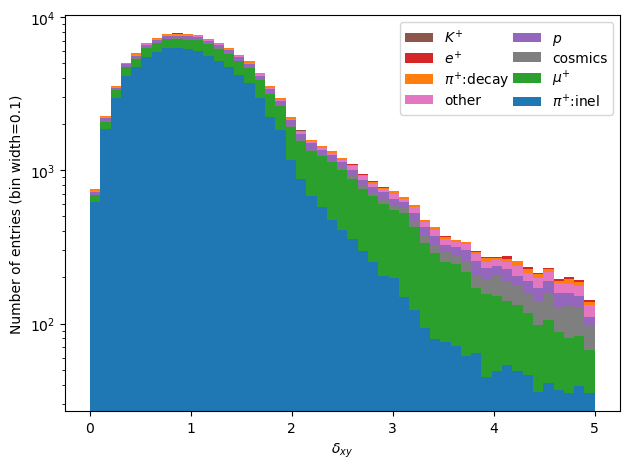

In [48]:
from python.analysis import Plots

tags = Tags.GenerateBeamCandidateTags(track_evts_pdsp)

particle_tags = tags.name.values
masks = {name: tags.get(name).mask for name in particle_tags}

bins = np.linspace(0, 5, 50)
plt.figure(figsize=(8, 6))
Plots.PlotTagged(beam_dxy, tags, bins=bins, y_scale='log', x_label=r'$\delta_{xy}$')

In [49]:
mask = beam_dxy < 3
track_selected_evts_pdsp = track_evts_pdsp.Filter([mask], [mask], returnCopy=True)

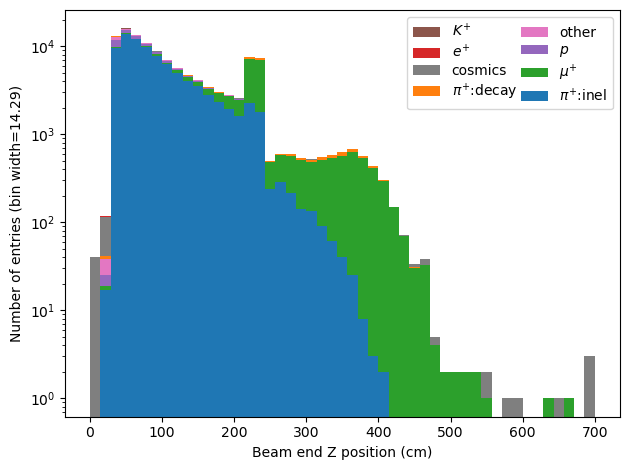

In [50]:
end_pos = track_selected_evts_pdsp.recoParticles.beam_endPos_SCE
tags = Tags.GenerateBeamCandidateTags(track_selected_evts_pdsp)
Plots.PlotTagged(end_pos.z, tags, bins=np.linspace(0, 700, 50), y_scale='log', x_label="Beam end Z position (cm)")

In [51]:
np.unique(events_pdsp.recoParticles.beam_particles), np.unique(track_selected_evts_pdsp.recoParticles.beam_particles)

(<Array [0, 1, 2, 3, 4] type='5 * int32'>, <Array [1, 2, 3] type='3 * int32'>)

In [52]:
bi_evts_pdsp.eventNum, bv_evts_pdsp.eventNum, track_evts_pdsp.eventNum, track_selected_evts_pdsp.eventNum

(<Array [812, 813, 816, 817, ... 700, 1173, 279] type='170238 * int32'>,
 <Array [812, 813, 817, 820, ... 1359, 346, 700] type='149791 * int32'>,
 <Array [812, 813, 817, 820, ... 469, 1359, 700] type='145004 * int32'>,
 <Array [812, 813, 817, 820, ... 469, 1359, 700] type='117818 * int32'>)

In [53]:
purity_eff_dict = {}
n_sig_true = ak.sum(beam_selection.true_signal_mask(events_pdsp))
n_sig_bt   = ak.sum(beam_selection.signal_mask(events_pdsp))

purity_eff_dict = {}
for evts, label in zip([events_pdsp, bi_evts_pdsp, bv_evts_pdsp, track_evts_pdsp, track_selected_evts_pdsp],
                        ["All events", "Beam trigger", "Beam valid", "Beam track", "Beam quality"]):
    purity_eff_dict[label] = {
        "Purity":                  float(ak.sum(beam_selection.signal_mask(evts))      / len(beam_selection.signal_mask(evts))),
        "True efficiency":         float(ak.sum(beam_selection.true_signal_mask(evts)) / n_sig_true),
        "Backtracked efficiency":  float(ak.sum(beam_selection.signal_mask(evts))      / n_sig_bt),
    }

pur_eff_df = pd.DataFrame(purity_eff_dict)
pur_eff_df.loc["Rel. true efficiency"] = pur_eff_df.loc["True efficiency"] / pur_eff_df.loc["True efficiency"].shift(1)
pur_eff_df.loc["Rel. BT efficiency"]   = pur_eff_df.loc["Backtracked efficiency"] / pur_eff_df.loc["Backtracked efficiency"].shift(1)

In [54]:
pur_eff_df.style.format("{:.1%}")

,All events,Beam trigger,Beam valid,Beam track,Beam quality
Purity,31.2%,54.6%,62.0%,63.5%,74.9%
True efficiency,100.0%,100.0%,87.6%,84.5%,69.9%
Backtracked efficiency,100.0%,99.8%,99.8%,99.0%,94.8%
Rel. true efficiency,nan%,100.0%,87.6%,96.4%,82.8%
Rel. BT efficiency,nan%,99.8%,100.0%,99.2%,95.7%
